<a href="https://colab.research.google.com/github/koomsonkell-png/actuarial-insurance-pricing-model/blob/main/Insurace_premuim_pricing_calculator%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Actuarial Insurance Premium Pricing Calculator in Python

## Project Overview

This project develops a Python-based actuarial pricing model for several life insurance products. The model calculates actuarial present values (APVs), variances, and standard deviations under specified mortality and interest rate assumptions.

The project covers:

- Whole Life Insurance
- Term Assurance
- Pure Endowment
- Endowment Assurance
- Variance Calculations
- Sensitivity Analysis

## What is Insuance pricing?
 Insurance pricing deals with determining the fair price of an insurance product based on risk assessments , statistical models , expected values , discounting principles , expense loading , profit margin etc.

## Why do Actuaries calculate premiums?
 Actuaries calculate premiums as to ensure that the insurer collects enough money to cover expected claims,operating expense and profit, while still competitive and solvent. They use statistical models to accurately price risk to prevent underpricing( which causes losses) and overpricing( which drives away customers)

## Objectives

The objectives of this project are to:

1. Calculate actuarial present values for various life insurance products.
2. Measure the variability of insurance liabilities using variance and standard deviation.
3. Examine the effect of changing interest rates on premium values.

## Assumptions

The model is developed under the following assumptions:

- Mortality rates remain constant throughout the policy term.
- Survival and death probabilities are independent from year to year.
- Benefits are paid at the end of the year of death or survival.
- A fixed annual effective interest rate is assumed.
- No expenses, taxes, or profit loadings are included.

Under the assumption of constant rate of mortality the curtate future lifetime random variable can be modelled with a geometric distribution thus $K_x$ ~ $Geometric(q_x)$   with PMF of   $P(K = k) = q_x p_x ^ k    ,    k = 0,1,2,3,... $

## Importing Required Libraries

The following libraries are used for numerical computation, data manipulation, and visualization.

In [ ]:
# Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Model Parameters

The following parameters are specified by the user and are used throughout the pricing calculations.
- x - Age of policy holder at the time of purchace
- q -  Probability of death
- b -  Benefit amount
- i - effective annual interest rate

# Whole Life Insurance

Whole life insurance provides a death benefit at the time of death of the insured person no matter when that time might.Under the mortality and interest rate assumptions, the actuarial present value and variance are determined by discounting future death benefits payments according to the formulas.

$APV = E(Z) = A_{x}$ = $\sum_{k=0}^{\infty}V^{k+1}q_{x}p_{x}^{k} = (bq_{x}v/1-p_{x}v)$                                                               
$Var(Z) =  {}^{2}A_{x} - (A_{x})^{2} = (b^{2}q_{x}v^{2}/1-p_{x}v^{2}) - (bq_{x}v/1-p_{x}v)^{2}$

In [ ]:

def whole_life_Present_Value(b,q,i): # Calculates the Acturail Present Value of a whole life insurance policy.
    p,v = 1 - q , 1/(1+i)
    w_l_pv = b*q*v/(1-(v*p))
    return b,i,q,w_l_pv

def whole_life_var_std(b,q,i): # Calculates the Varoance and standard deviatioin of the whole life insurance policy
    p,v = 1 - q , 1/(1+i)
    sec_moment = ((b**2)*q*(v**2))/(1-p*(v**2))
    first_moment = whole_life_Present_Value(b,q,i)[3]
    return  sec_moment - (first_moment**2), (sec_moment - (first_moment**2))**0.5


print("-----------------------------Summary----------------------------------------")
print(f"Benefit Amount                   |             {whole_life_Present_Value(100000,0.20,0.12)[0]}          ")
print(f"Interest rate                    |             {whole_life_Present_Value(100000,0.20,0.12)[1]}          ")
print(f"Probability of death             |             {whole_life_Present_Value(100000,0.20,0.12)[2]}          ")
print(f"Net Present Value                |             {whole_life_Present_Value(100000,0.20,0.12)[3]:.2f}")
print(f"Variance and Standard Deviation  |  {whole_life_var_std(100000,0.2,0.12)}")

-----------------------------Summary----------------------------------------
Benefit Amount                   |             100000          
Interest rate                    |             0.12          
Probability of death             |             0.2          
Net Present Value                |             62500.00
Variance and Standard Deviation  |  (495158450.70422554, 22252.156091134755)


# Term Assurance
An n-year term life insurance payable at the end of year of death is a policy where the payment is made only when the insured person dies within n years of the policy's issue, thus if the policyholder survives beyond the term, no benefit is payable.
Under the mortality and interest rate assumptions, we have the present value and variance to be calculated as follows;

$APV = E(Z) = A_{x:\overline{n}|}^{1}$ = $\sum_{k=0}^{n-1}V^{k+1}q_{x}p_{x}^{k} = bvq_{x}((1-v^{n}p_{x}^{n})/1-vp_x)$               
$Var(Z) =  {}^{2}A^{1}_{x:\overline{n}|} - (A^{1}_{x:\overline{n}|})^{2} = [b^{2}v^{2}q_{x}(1-p_{x}^{n}v^{2n}/1-p_{x}v^{2})] - [bvq_{x}(1-v^{n}p_{x}^{n}/1-vp_{x})]^{2}$

In [ ]:
def term_assurance_present_value(b,q,i,n):
    p ,v = 1-q , 1/(1+i)
    tpv = b * v * q *((1-(v**n)*(p**n))/(1-v*p))
    return b,i,q,tpv

def term_assurance_var__std(b,q,i,n):
    p ,v = 1-q , 1/(1+i)
    sec_moment = (b**2) * (v**2) * q *((1-(p**n)*(v**(2*n)))/(1-p*(v**2)))
    first_moment = term_assurance_present_value(b,q,i,n)[3]
    tvar = sec_moment - (first_moment**2)
    return tvar , (tvar**0.5)

print("-----------------------------Summary----------------------------------------")
print(f"Benefit Amount                   |             {term_assurance_present_value(100000,0.20,0.12,5)[0]}")
print(f"Interest rate                    |              {term_assurance_present_value(100000,0.20,0.12,5)[1]}")
print(f"Probability of death             |              {term_assurance_present_value(100000,0.20,0.12,5)[2]}")
print(f"Net Present Value                |            {term_assurance_present_value(100000,0.20,0.12,5)[3]:.2f}")
print(f"Variance and Standard Deviation  |  {term_assurance_var__std(100000,0.2,0.12,5)}")

-----------------------------Summary----------------------------------------
Benefit Amount                   |             100000
Interest rate                    |              0.12
Probability of death             |              0.2
Net Present Value                |            50879.10
Variance and Standard Deviation  |  (1348358803.7497978, 36720.00549768202)


# Pure Endowment
An n-year pure endowment provides a payment at the end of n years if the policy holder survives , but makes no payment if the policy holder dies within n years.
Under the mortatlity and interest rate assumption we have the present value and variance calculated as follows ;

$APV = E(Z) = {}_{n}E_{x} = v^{n}{}_{n}p_{x} = A_{{x:\overline{n}}|^{1}}$ = $b(vp_{x})^{n}$               
$Var(Z) =  {}^{2}A_{x:\overline{n}|^{1}} - (A_{{x:\overline{n}}|^{1}})^{2} = v^{2n}{}_{n}p_{x}{}_{n}q_{x} = b^{2}v^{2n}p_{x}^{n}[1-p_{x}^{n}]$

In [ ]:
def pure_endowmwnt_present_value(b,q,i,n):
    p ,v = 1-q , 1/(1+i)
    p_e_pv = b*((v*p)**n)
    return b,i,q,p_e_pv

def pure_endowment_var__std(b,q,i,n):
    p ,v = 1-q , 1/(1+i)
    p_e_var = (b**2)*(v**(2*n))*(p**n)*(1-(p**n))
    return p_e_var , (p_e_var**0.5)


print("-----------------------------Summary----------------------------------------")
print(f"Benefit Amount                   |              {pure_endowmwnt_present_value(100000,0.20,0.12,5)[0]}     ")
print(f"Interest rate                    |               {pure_endowmwnt_present_value(100000,0.20,0.12,5)[1]}      ")
print(f"Probability of death             |               {pure_endowmwnt_present_value(100000,0.20,0.12,5)[2]}  ")
print(f"Net Present Value                |             {pure_endowmwnt_present_value(100000,0.20,0.12,5)[3]:.2f}")
print(f"Variance and Standard Deviation  |  {pure_endowment_var__std(100000,0.2,0.12,5)}")

-----------------------------Summary----------------------------------------
Benefit Amount                   |              100000     
Interest rate                    |               0.12      
Probability of death             |               0.2  
Net Present Value                |             18593.44
Variance and Standard Deviation  |  (709325771.3243153, 26633.170508302523)


# Endowment Assurance

An n-year Endowment insurance payable at the end of year of death provides an amount to be paid at the end of year of death if death occurs in the next n years or at the end of year n if policyholder survives to that time
An endowment assurance combines features of term assurance and pure endowment.
Under the mortality and interest rate assumptions we have the present value and variance to be;

$APV = E(Z) = A_{x:\overline{n}|} = A_{x:\overline{n}|}^{1} + A_{{x:\overline{n}}|^{1}} =  \sum_{k=0}^{n-1}V^{k+1}q_{x}p_{x}^{k} + v^{n}{}_{n}p_{x} = b[vq_{x}((1-v^{n}p_{x}^{n})/1-vp_x) + (vp_{x})^{n}]$

$Var(Z) =  {}^{2}A_{x:\overline{n}|} - (A_{x:\overline{n}|})^{2}------  where ------- {}^{2}A_{x:\overline{n}|} = {}^{2}A^{1}_{x:\overline{n}|} + {}^{2}A_{x:\overline{n}|^{1}}$

In [ ]:
def Endowmwnt_present_value(b,q,i,n):
    e_pv = term_assurance_present_value(b,q,i,n)[3] + pure_endowmwnt_present_value(b,q,i,n)[3]
    return b,i,q,e_pv

def Endowment_var__std(b,q,i,n):
    second_moment = (term_assurance_var__std(b,q,i,n)[0]+(term_assurance_present_value(b,q,i,n)[3]**2)) + (pure_endowment_var__std(b,q,i,n)[0]+(pure_endowmwnt_present_value(b,q,i,n)[3]**2))
    e_var = second_moment - (Endowmwnt_present_value(b,q,i,n)[3]**2)
    return e_var , (e_var**0.5)

print("-----------------------------Summary----------------------------------------")
print(f"Benefit Amount                   |             {Endowmwnt_present_value(100000,0.20,0.12,5)[0]}       ")
print(f"Interest rate                    |             {Endowmwnt_present_value(100000,0.20,0.12,5)[1]}      ")
print(f"Probability of death             |             {Endowmwnt_present_value(100000,0.20,0.12,5)[2]}      ")
print(f"Net Present Value                |             {Endowmwnt_present_value(100000,0.20,0.12,5)[3]:.2f}")
print(f"Variance and Standard Deviation  |  {Endowment_var__std(100000,0.2,0.12,5)}")


-----------------------------Summary----------------------------------------
Benefit Amount                   |             100000       
Interest rate                    |             0.12      
Probability of death             |             0.2      
Net Present Value                |             69472.54
Variance and Standard Deviation  |  (165649336.9708271, 12870.483167730226)


# Sensitivity Analysis: Impact of Interest Rates On Insurance Products

Interest rates influences the present value of all insurance products because future benefits are discounted to their present value.

The graph below compares the response of:

- Whole Life Insurance
- Term Assurance
- Pure Endowment
- Endowment Assurance

to changes in the annual effective interest rate.

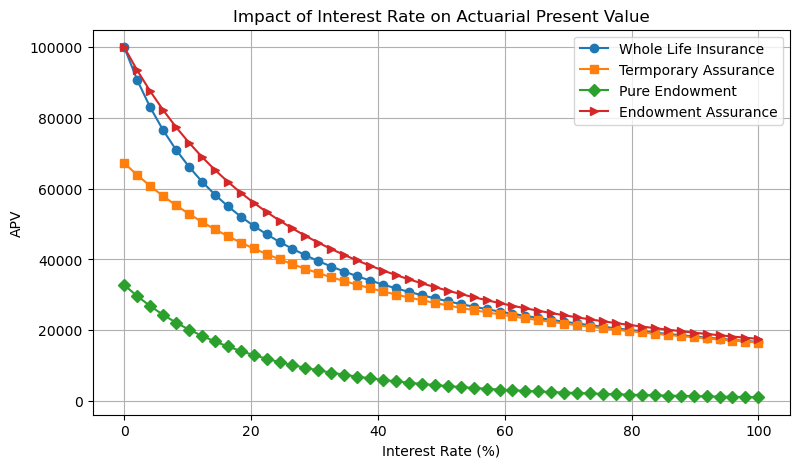

In [ ]:
amount = 100000
n=5
prob_death = 0.2
annual_interest_rate = 0.12

x_interest_rates = np.linspace(0,1)

y_whole_life = []
for w in x_interest_rates:
    y_whole_life.append(whole_life_Present_Value(amount,prob_death,w)[3])
y_term_assurance = []
for t in x_interest_rates:
    y_term_assurance.append(term_assurance_present_value(amount,prob_death,t,n)[3])
y_pure_endowment = []
for p in x_interest_rates:
    y_pure_endowment.append(pure_endowmwnt_present_value(amount,prob_death,p,n)[3])
y_endowment = []
for e in x_interest_rates:
    y_endowment.append(Endowmwnt_present_value(amount,prob_death,e,n)[3])

plt.figure(figsize=(9,5))
plt.plot(x_interest_rates*100, y_whole_life, marker='o',label = "Whole Life Insurance")
plt.plot(x_interest_rates*100,y_term_assurance,marker="s",label = "Termporary Assurance")
plt.plot(x_interest_rates*100,y_pure_endowment,marker="D",label = "Pure Endowment")
plt.plot(x_interest_rates*100,y_endowment,marker=">",label = "Endowment Assurance")

plt.title("Impact of Interest Rate on Actuarial Present Value")
plt.xlabel("Interest Rate (%)")
plt.ylabel("APV")
plt.grid(True)
plt.legend()

plt.show()


### Interpretation

The graph confirms the inverse relationship between interest rates and actuarial present values.

As interest rates increase, discounting factor decreases, hence, reducing the present value of future benefit payments.

# Sensitivity Analysis: Comparing Insurance Products Premiums

Question:

Which product has the highest Premium?

The graph below answers the question of which product has the highest present value for:

- Whole Life Insurance
- Term Assurance
- Pure Endowment
- Endowment Assurance

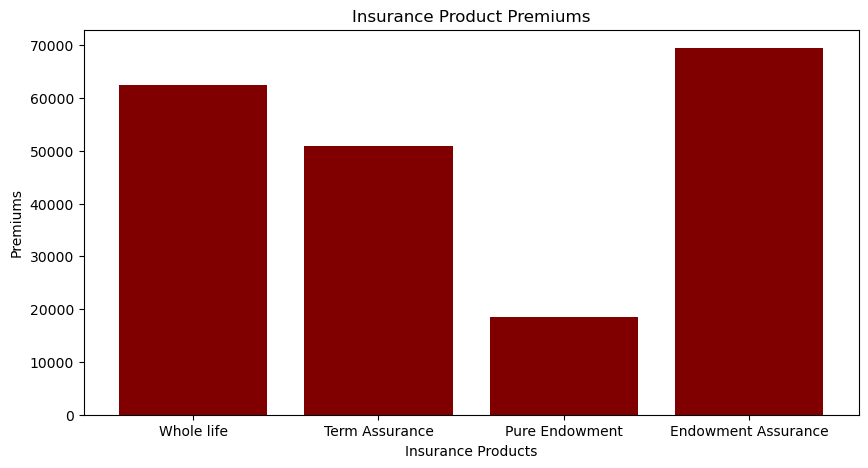

In [ ]:
amount = 100000
n=5
prob_death = 0.2
annual_interest_rate = 0.12

x_products = ["Whole life","Term Assurance","Pure Endowment","Endowment Assurance"]

y_APV = []
y_APV.append(whole_life_Present_Value(amount,prob_death,annual_interest_rate)[3])
y_APV.append(term_assurance_present_value(amount,prob_death,annual_interest_rate,n)[3])
y_APV.append(pure_endowmwnt_present_value(amount,prob_death,annual_interest_rate,n)[3])
y_APV.append(Endowmwnt_present_value(amount,prob_death,annual_interest_rate,n)[3])


plt.figure(figsize=(10,5))
plt.bar(x_products,y_APV,color = "maroon")
plt.title("Insurance Product Premiums")
plt.xlabel("Insurance Products")
plt.ylabel("Premiums")

plt.show()

### Interpretation

Clearly the graph confirms that for a given sum assured , coverage period , probability of death and interest rate ,the Endowment Assurance has the highest premium compared to the rest with Pure Endowment having the lowerst premium..

# Sensitivity Analysis: Comparing Insurance Products Risk

Question:

Which insurance product carries the greatest uncertainty/Risk?

The graph below answers the question of which product has the highest risk for :

- Whole Life Insurance
- Term Assurance
- Pure Endowment
- Endowment Assurance

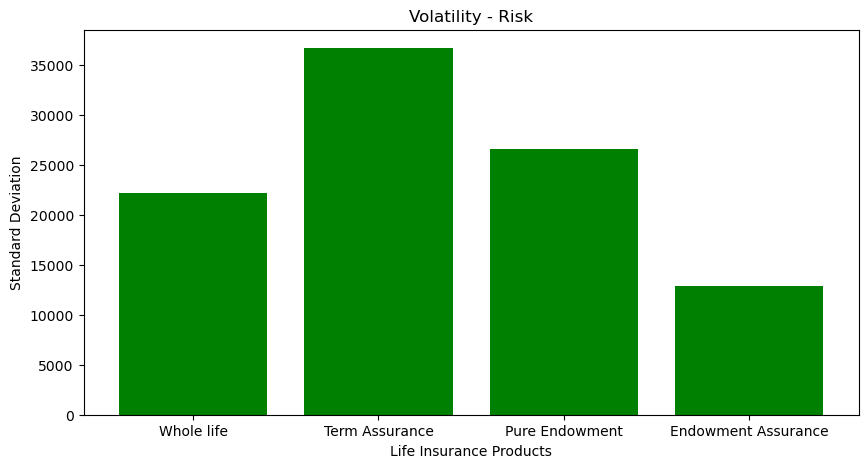

In [ ]:
amount = 100000
n=5
prob_death = 0.2
annual_interest_rate = 0.12

x_products = ["Whole life","Term Assurance","Pure Endowment","Endowment Assurance"]

y_risk = []
y_risk.append(whole_life_var_std(amount,prob_death,annual_interest_rate)[1])
y_risk.append(term_assurance_var__std(amount,prob_death,annual_interest_rate,n)[1])
y_risk.append(pure_endowment_var__std(amount,prob_death,annual_interest_rate,n)[1])
y_risk.append(Endowment_var__std(amount,prob_death,annual_interest_rate,n)[1])


plt.figure(figsize=(10,5))
plt.bar(x_products,y_risk,color = "green")
plt.title("Volatility - Risk")
plt.xlabel("Life Insurance Products")
plt.ylabel("Standard Deviation")

plt.show()

### Interpretation

Again the graph shows that for a given sum assured , coverage period , probability of death and interest rate ,the Endowment Assurance has the least risk compared to the rest with term assurance having the highest risk..

# Sensitivity of Insurance Products to Mortality Assumptions

Question:

What happens when mortality increases?

Different insurance products respond differently to changes in mortality rates because their benefit payments depend on either survival, death, or both.

To compare these effects, actuarial present values (APVs) are calculated across a range of mortality rates for:

- Whole Life Insurance
- Term Assurance
- Pure Endowment
- Endowment Assurance

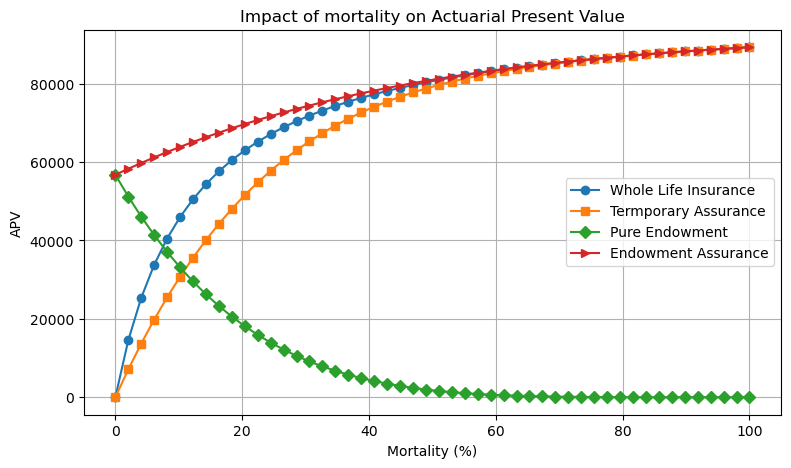

In [ ]:
amount = 100000
n=5
prob_death = 0.2
annual_interest_rate = 0.12

x_mortality = np.linspace(0,1)

y_m_whole_life = []
for w in x_mortality:
    y_m_whole_life.append(whole_life_Present_Value(amount,w,annual_interest_rate)[3])
y_m_term_assurance = []
for t in x_mortality:
    y_m_term_assurance.append(term_assurance_present_value(amount,t,annual_interest_rate,n)[3])
y_m_pure_endowment = []
for p in x_mortality:
    y_m_pure_endowment.append(pure_endowmwnt_present_value(amount,p,annual_interest_rate,n)[3])
y_m_endowment = []
for e in x_mortality:
    y_m_endowment.append(Endowmwnt_present_value(amount,e,annual_interest_rate,n)[3])

plt.figure(figsize=(9,5))
plt.plot(x_mortality*100, y_m_whole_life, marker='o',label = "Whole Life Insurance")
plt.plot(x_mortality*100,y_m_term_assurance,marker="s",label = "Termporary Assurance")
plt.plot(x_mortality*100,y_m_pure_endowment,marker="D",label = "Pure Endowment")
plt.plot(x_mortality*100,y_m_endowment,marker=">",label = "Endowment Assurance")

plt.title("Impact of mortality on Actuarial Present Value")
plt.xlabel("Mortality (%)")
plt.ylabel("APV")
plt.grid(True)
plt.legend()

plt.savefig("mortality_sensitivity.png", dpi=300, bbox_inches="tight")
plt.show()


### Interpretation

The graph demonstrates that as mortality rates increase:

- Whole Life Insurance and Term Assurance generally become more valuable because death benefits are expected to be paid sooner.
- Pure Endowment becomes less valuable because fewer policyholders are expected to survive to the maturity date.
- Endowment Assurance exhibits a mixed response because it combines both death and survival benefits.

# Sensitivity Analysis: Impact of Benefit Amount on Actuarial Present Value

The benefit amount, also known as the sum assured, determines the size of the payment made by the insurer when the insured event occurs.

This analysis investigates how the actuarial present value changes as the benefit amount increases  across various life insurance products;

- Whole Life Insurance
- Term Assurance
- Pure Endowment
- Endowment Assurance


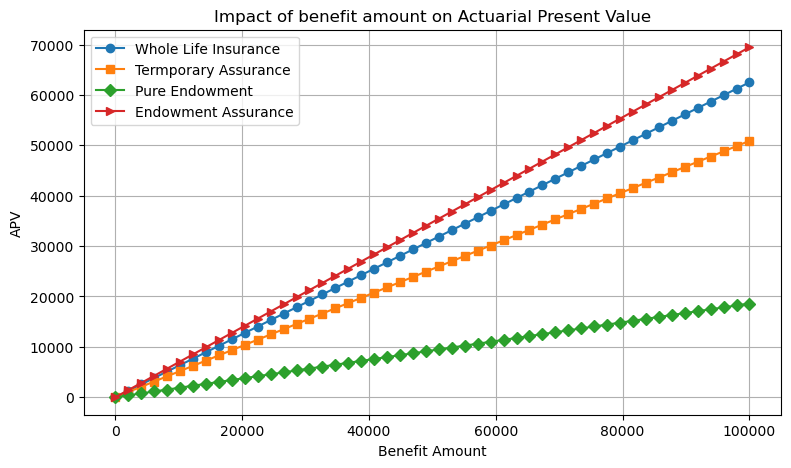

In [ ]:
amount = 100000
n=5
prob_death = 0.2
annual_interest_rate = 0.12

x_amount = np.linspace(0,100000)

y_a_whole_life = []
y_a_term_assurance = []
y_a_pure_endowment = []
y_a_endowment = []

for a in x_amount:
    y_a_whole_life.append(whole_life_Present_Value(a,prob_death,annual_interest_rate)[3])
    y_a_term_assurance.append(term_assurance_present_value(a,prob_death,annual_interest_rate,n)[3])
    y_a_pure_endowment.append(pure_endowmwnt_present_value(a,prob_death,annual_interest_rate,n)[3])
    y_a_endowment.append(Endowmwnt_present_value(a,prob_death,annual_interest_rate,n)[3])

plt.figure(figsize=(9,5))
plt.plot(x_amount, y_a_whole_life, marker='o',label = "Whole Life Insurance")
plt.plot(x_amount,y_a_term_assurance,marker="s",label = "Termporary Assurance")
plt.plot(x_amount,y_a_pure_endowment,marker="D",label = "Pure Endowment")
plt.plot(x_amount,y_a_endowment,marker=">",label = "Endowment Assurance")

plt.title("Impact of benefit amount on Actuarial Present Value")
plt.xlabel("Benefit Amount")
plt.ylabel("APV")
plt.grid(True)
plt.legend()

plt.show()

### Interpretation

The graph shows a positive relationship between the benefit amount and the actuarial present value.

As the benefit amount increases, the expected payment made by the insurer also increases, leading to higher present values, thus ,larger insurance benefits require higher premiums to compensate for the increased liability.

# Conclusion

The analysis showed that different insurance products respond differently to changes in mortality,interest rate and benefit amount highlighting the importance of accurate assumptions in pricing and risk assessment. Overall, the project strengthened both my actuarial modelling and Python programming skills while demonstrating how computational tools can support insurance decision-making.